In [ ]:
library(ArchR)
library(dplyr)


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .______      
          /   \     |   _ 

In [ ]:
addArchRThreads(threads = 12)

Setting default number of Parallel threads to 12.



In [ ]:
addArchRGenome("hg38")

Setting default genome to Hg38.



# Arrow generation and setup

In [ ]:
# current files
inputFiles = read.table('../data/atac/fragment_files.txt', header=F) %>%
.$V1
names(inputFiles) = gsub("^.*/cell(.*?)/atac_fragments.tsv.gz", "cell\\1", inputFiles)

In [ ]:
setwd('../data/atac/')

In [ ]:
ArrowFiles <- createArrowFiles(
  inputFiles = inputFiles,
  sampleNames = names(inputFiles),
  minTSS = 4, #Dont set this too high because you can always increase later
  minFrags = 1000, 
  addTileMat = TRUE,
  addGeneScoreMat = TRUE
)

Using GeneAnnotation set by addArchRGenome(Hg38)!

Using GeneAnnotation set by addArchRGenome(Hg38)!

ArchR logging to : ArchRLogs/ArchR-createArrows-3e2c9624082f1e-Date-2026-08-22_Time-14-32-37.48911.log
If there is an issue, please report to github with logFile!

Cleaning Temporary Files

subThreading Disabled since ArchRLocking is TRUE see `addArchRLocking`

2026-08-22 14:32:38.1195 : Batch Execution w/ safelapply!, 0 mins elapsed.

ArchR logging successful to : ArchRLogs/ArchR-createArrows-3e2c9624082f1e-Date-2026-08-22_Time-14-32-37.48911.log



In [ ]:
doubScores <- addDoubletScores(
  input = ArrowFiles,
  k = 10, #Refers to how many cells near a "pseudo-doublet" to count.
  knnMethod = "UMAP", #Refers to the embedding to use for nearest neighbor search.
  LSIMethod = 1
)

ArchR logging to : ArchRLogs/ArchR-addDoubletScores-8539573f02-Date-2022-10-05_Time-09-51-36.log
If there is an issue, please report to github with logFile!

2022-10-05 09:51:36 : Batch Execution w/ safelapply!, 0 mins elapsed.

2022-10-05 09:51:36 : cellranger-arc201_count_9c3fd7a279c3fe95e496b4b7235bff87 (1 of 96) :  Computing Doublet Statistics, 0.001 mins elapsed.

Warning message:
“package ‘Seurat’ was built under R version 4.0.5”
cellranger-arc201_count_9c3fd7a279c3fe95e496b4b7235bff87 (1 of 96) : UMAP Projection R^2 = 0.98229

cellranger-arc201_count_9c3fd7a279c3fe95e496b4b7235bff87 (1 of 96) : UMAP Projection R^2 = 0.98229

2022-10-05 10:01:29 : cellranger-arc201_count_6e347d162d04f3cee707c8c90da8f079 (2 of 96) :  Computing Doublet Statistics, 9.884 mins elapsed.

cellranger-arc201_count_6e347d162d04f3cee707c8c90da8f079 (2 of 96) : UMAP Projection R^2 = 0.86391

cellranger-arc201_count_6e347d162d04f3cee707c8c90da8f079 (2 of 96) : UMAP Projection R^2 = 0.86391

2022-10-05 11:00:

# Load object

In [ ]:
ArrowFiles <- Sys.glob("../data/atac/*arrow")

In [ ]:
proj <- ArchRProject(
  ArrowFiles = ArrowFiles, 
  outputDirectory = "../data/atac/",
  copyArrows = FALSE #This is recommened so that you maintain an unaltered copy for later usage.
)

Using GeneAnnotation set by addArchRGenome(Hg38)!

Using GeneAnnotation set by addArchRGenome(Hg38)!

Warning message in normalizePath(outputDirectory):
“path[1]="/lustre/scratch117/cellgen/team283/gd11/data_GBM/arrow/multiome/": No such file or directory”
Warning message in normalizePath(outputDirectory):
“path[1]="/lustre/scratch117/cellgen/team283/gd11/data_GBM/arrow/multiome/": No such file or directory”
Validating Arrows...

Getting SampleNames...



Getting Cell Metadata...



Merging Cell Metadata...

Initializing ArchRProject...

Warning message in normalizePath(outputDirectory):
“path[1]="/lustre/scratch117/cellgen/team283/gd11/data_GBM/arrow/multiome/": No such file or directory”

                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                

# Quality control

## Load GEX barcodes

In [ ]:
GEX_barcodes <- read.csv(
  "../data/metadata/cell_metadata_all.csv",
  row.names = 1
)

In [ ]:
df <- getCellColData(proj, select = c("log10(nFrags)", "TSSEnrichment"))
df_filtered_gex <- df[rownames(df) %in% GEX_barcodes$cell_id,]

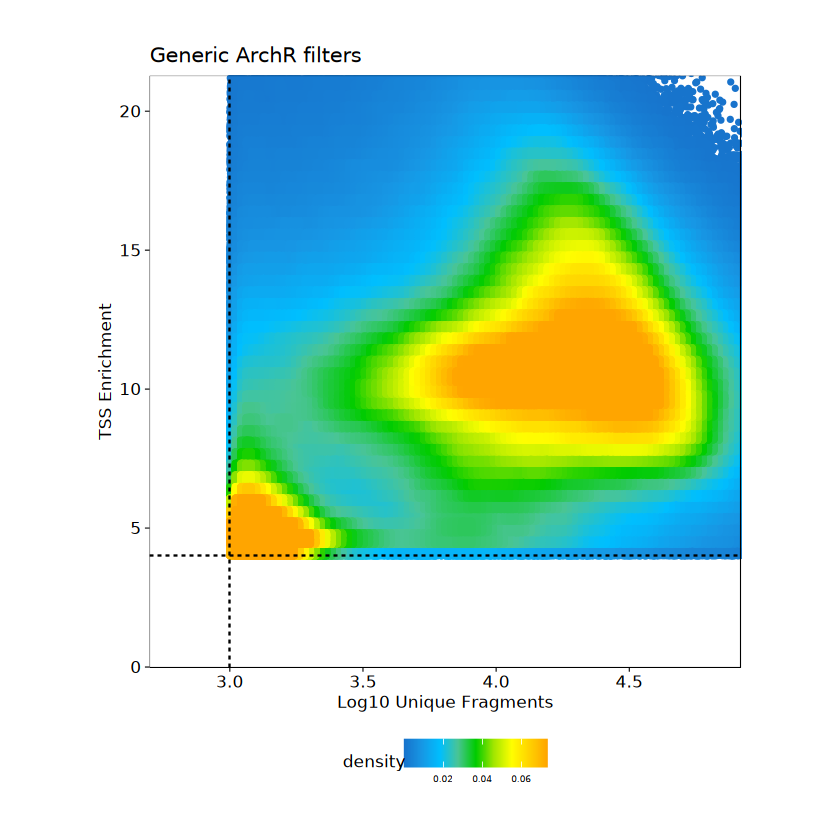

In [ ]:
p <- ggPoint(
    x = df[,1], 
    y = df[,2], 
    colorDensity = TRUE,
    continuousSet = "sambaNight",
    title = "Generic ArchR filters",
    xlabel = "Log10 Unique Fragments",
    ylabel = "TSS Enrichment",
    xlim = c(log10(500), quantile(df[,1], probs = 0.99)),
    ylim = c(0, quantile(df[,2], probs = 0.99))
) + geom_hline(yintercept = 4, lty = "dashed") + geom_vline(xintercept = 3, lty = "dashed")

p

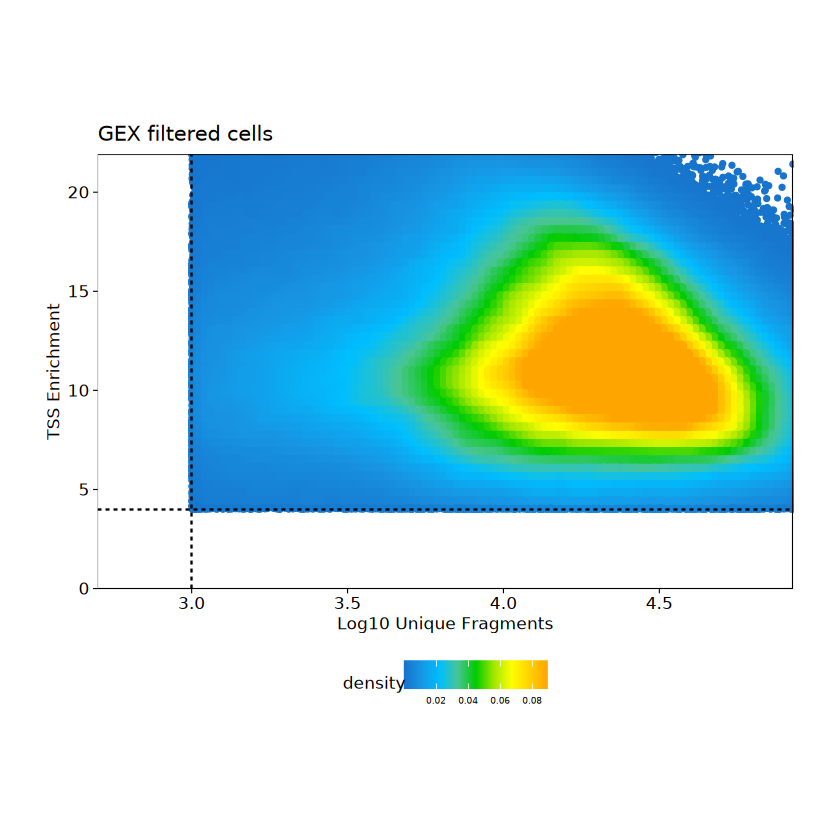

In [ ]:
p <- ggPoint(
    x = df_filtered_gex[,1], 
    y = df_filtered_gex[,2], 
    colorDensity = TRUE,
    continuousSet = "sambaNight",
    title = "GEX filtered cells",
    xlabel = "Log10 Unique Fragments",
    ylabel = "TSS Enrichment",
    xlim = c(log10(500), quantile(df_filtered_gex[,1], probs = 0.99)),
    ylim = c(0, quantile(df_filtered_gex[,2], probs = 0.99))
) + geom_hline(yintercept = 4, lty = "dashed") + geom_vline(xintercept = 3, lty = "dashed") + 
theme(aspect.ratio = 5 / 8)

p

In [ ]:
# final plots:

library(ggrastr)

p <- ggPoint(
    x = df[,1], 
    y = df[,2], 
    colorDensity = TRUE,
    continuousSet = "sambaNight",
    title = "Generic ArchR filters",
    xlabel = "Log10 Unique Fragments",
    ylabel = "TSS Enrichment",
    xlim = c(log10(500), quantile(df[,1], probs = 0.99)),
    ylim = c(0, quantile(df[,2], probs = 0.99))
)

# Rasterise the point/density layer only
p$layers[[1]] <- rasterise(p$layers[[1]], dpi = 300)

p <- p +
    geom_hline(yintercept = 4, lty = "dashed") +
    geom_vline(xintercept = 3, lty = "dashed") + 
theme(aspect.ratio = 5 / 8)

ggsave(
    "../plots/TSS_pre_filter.pdf",
    p,
    width = 8,
    height = 5,
    device = cairo_pdf
)

In [ ]:
# final plots:

library(ggrastr)

p <- ggPoint(
    x = df_filtered_gex[,1], 
    y = df_filtered_gex[,2], 
    colorDensity = TRUE,
    continuousSet = "sambaNight",
    title = "Generic ArchR filters",
    xlabel = "Log10 Unique Fragments",
    ylabel = "TSS Enrichment",
    xlim = c(log10(500), quantile(df_filtered_gex[,1], probs = 0.99)),
    ylim = c(0, quantile(df_filtered_gex[,2], probs = 0.99))
)

# Rasterise the point/density layer only
p$layers[[1]] <- rasterise(p$layers[[1]], dpi = 300)

p <- p +
    geom_hline(yintercept = 4, lty = "dashed") +
    geom_vline(xintercept = 3, lty = "dashed") + 
theme(aspect.ratio = 5 / 8)

ggsave(
    "../plots/TSS_post_filter.pdf",
    p,
    width = 8,
    height = 5,
    device = cairo_pdf
)

In [ ]:
df2 <- getCellColData(proj, select = c("log10(nFrags)", "PromoterRatio"))
df_filtered_gex2 <- df2[rownames(df2) %in% GEX_barcodes$cell_id,]

In [ ]:
# final plots:

library(ggrastr)

p <- ggPoint(
    x = df_filtered_gex2[,1], 
    y = df_filtered_gex2[,2], 
    colorDensity = TRUE,
    continuousSet = "sambaNight",
    title = "Generic ArchR filters",
    xlabel = "Log10 Unique Fragments",
    ylabel = "PromoterRatio",
    xlim = c(log10(500), quantile(df_filtered_gex2[,1], probs = 0.99)),
    ylim = c(0, quantile(df_filtered_gex2[,2], probs = 0.99))
)

# Rasterise the point/density layer only
p$layers[[1]] <- rasterise(p$layers[[1]], dpi = 300)

p <- p +
    geom_vline(xintercept = 0.1, lty = "dashed") + 
theme(aspect.ratio = 5 / 8)

ggsave(
    "../plots/promoter_ratio_post_filter.pdf",
    p,
    width = 8,
    height = 5,
    device = cairo_pdf
)

## Filter Doublets

In [ ]:
#proj <- filterDoublets(ArchRProj = proj)

In [ ]:
df_PD <- getCellColData(proj, select = c("log10(nFrags)", "TSSEnrichment"))

In [ ]:
df_PD_filtered_gex <- df_PD[rownames(df_PD) %in% GEX_barcodes$sample_barcodes,]

In [ ]:
p <- ggPoint(
    x = df_filtered_gex[,1], 
    y = df_filtered_gex[,2], 
    colorDensity = TRUE,
    continuousSet = "sambaNight",
    title = "GEX filtered cells + Seurat doublet removal",
    xlabel = "Log10 Unique Fragments",
    ylabel = "TSS Enrichment",
    xlim = c(log10(500), quantile(df_filtered_gex[,1], probs = 0.99)),
    ylim = c(0, quantile(df_filtered_gex[,2], probs = 0.99))
) + geom_hline(yintercept = 4, lty = "dashed") + geom_vline(xintercept = 3, lty = "dashed")

p

## Main filter

In [ ]:
proj = proj[rownames(proj@cellColData) %in% GEX_barcodes$sample_barcodes,]

In [ ]:
tmpFile = ArchR:::.tempfile(tmpdir = "/tmp/")

# Clustering

In [ ]:
proj <- addIterativeLSI(
    ArchRProj = proj,
    useMatrix = "TileMatrix", 
    name = "IterativeLSI", 
    outlierQuantiles = NULL,
    iterations = 2, 
    clusterParams = list( #See Seurat::FindClusters
        sampleCells = 10000, 
        n.start = 10
    ), 
    varFeatures = 15000,
    dimsToUse = 1:30,
    sampleCellsPre = 100000,
    projectCellsPre=T,
    sampleCellsFinal = 200000
    
)

Checking Inputs...

ArchR logging to : ArchRLogs/ArchR-addIterativeLSI-b12e663f4fdd-Date-2022-11-11_Time-18-57-31.log
If there is an issue, please report to github with logFile!

2022-11-11 18:57:54 : Computing Total Across All Features, 0.332 mins elapsed.

2022-11-11 18:59:39 : Computing Top Features, 2.069 mins elapsed.

###########
2022-11-11 18:59:43 : Running LSI (1 of 2) on Top Features, 2.135 mins elapsed.
###########

2022-11-11 18:59:45 : Sampling Cells (N = 100052) for Estimated LSI, 2.168 mins elapsed.

2022-11-11 18:59:45 : Creating Sampled Partial Matrix, 2.168 mins elapsed.

2022-11-11 18:59:45 : Sampling Cells (N = 100052) for Estimated LSI, 2.168 mins elapsed.

2022-11-11 19:22:36 : Computing Estimated LSI (projectAll = TRUE), 25.024 mins elapsed.

2022-11-11 19:24:36 : Projecting Matrices with LSI-Projection (Granja* et al 2019), 27.022 mins elapsed.

2022-11-11 19:38:09 : Identifying Clusters, 40.578 mins elapsed.

2022-11-11 19:42:40 : Identified 15 Clusters, 45.093

In [ ]:
proj <- addHarmony(
    ArchRProj = proj,
    reducedDims = "IterativeLSI",
    name = "Harmony",
    groupBy = "Sample"
)

Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 36390750)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 36390750)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 36390750)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 36390750)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 36390750)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 36390750)”
Harmony 1/10

Harmony 2/10

Harmony 3/10

Harmony converged after 3 iterations



In [ ]:
proj <- addClusters(
    input = proj,
    reducedDims = "IterativeLSI",
    method = "Seurat",
    name = "Clusters",
    resolution = 0.8
)

ArchR logging to : ArchRLogs/ArchR-addClusters-b12e2834bc-Date-2022-11-12_Time-20-16-05.log
If there is an issue, please report to github with logFile!

2022-11-12 20:16:08 : Running Seurats FindClusters (Stuart et al. Cell 2019), 0.046 mins elapsed.

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 727815
Number of edges: 19065313

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9421
Number of communities: 266
Elapsed time: 982 seconds


224 singletons identified. 42 final clusters.

2022-11-12 21:19:24 : Testing Biased Clusters, 63.32 mins elapsed.

2022-11-12 21:19:45 : Testing Outlier Clusters, 63.661 mins elapsed.

2022-11-12 21:19:45 : Assigning Outlier Clusters (n = 2, nOutlier < 5 cells) to Neighbors, 63.662 mins elapsed.

2022-11-12 21:19:47 : Identified more clusters than maxClusters allowed (n = 2). Merging clusters to maxClusters (n = 25).
If this is not desired set maxClusters = NULL!, 63.697 mins elapsed.

2022-11-12 21:19:52 : Assigning Cluster Names to 25 Clusters, 63.786 mins elapsed.

2022-11-12 21:19:53 : Finished addClusters, 63.807 mins elapsed.



In [ ]:
#proj <- addClusters(input = proj, reducedDims = "IterativeLSI")

In [ ]:
write.table(proj@cellColData, "../data/metadata/ATAC_clusters.csv")

In [ ]:
proj <- addUMAP(
    ArchRProj = proj, 
    reducedDims = "IterativeLSI", 
    name = "UMAP", 
    nNeighbors = 30, 
    minDist = 0.5, 
    metric = "cosine"
)

09:43:49 UMAP embedding parameters a = 0.583 b = 1.334

09:43:49 Read 727815 rows and found 30 numeric columns

09:43:49 Using Annoy for neighbor search, n_neighbors = 30

09:43:49 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

09:46:28 Writing NN index file to temp file /lustre/scratch117/cellgen/team283/gd11/tmp//RtmpZV5GUY/fileb12e6ef22ec9

09:46:44 Searching Annoy index using 30 threads, search_k = 3000

09:48:01 Annoy recall = 100%

09:48:19 Commencing smooth kNN distance calibration using 30 threads
 with target n_neighbors = 30

09:49:10 Initializing from normalized Laplacian + noise (using irlba)

09:52:15 Commencing optimization for 200 epochs, with 35403302 positive edges

10:00:10 Optimization finished

10:00:10 Creating temp model dir /lustre/scratch117/ce

In [ ]:
p1 <- plotEmbedding(ArchRProj = proj, colorBy = "cellColData", name = "Sample", embedding = "UMAP", show.legend = FALSE)+ 
theme(legend.position = "none")

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-b12eac64b5-Date-2022-11-14_Time-10-10-36.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = cellColData

Plotting Embedding

1 
Length of unique values greater than palette, interpolating..



ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-b12eac64b5-Date-2022-11-14_Time-10-10-36.log



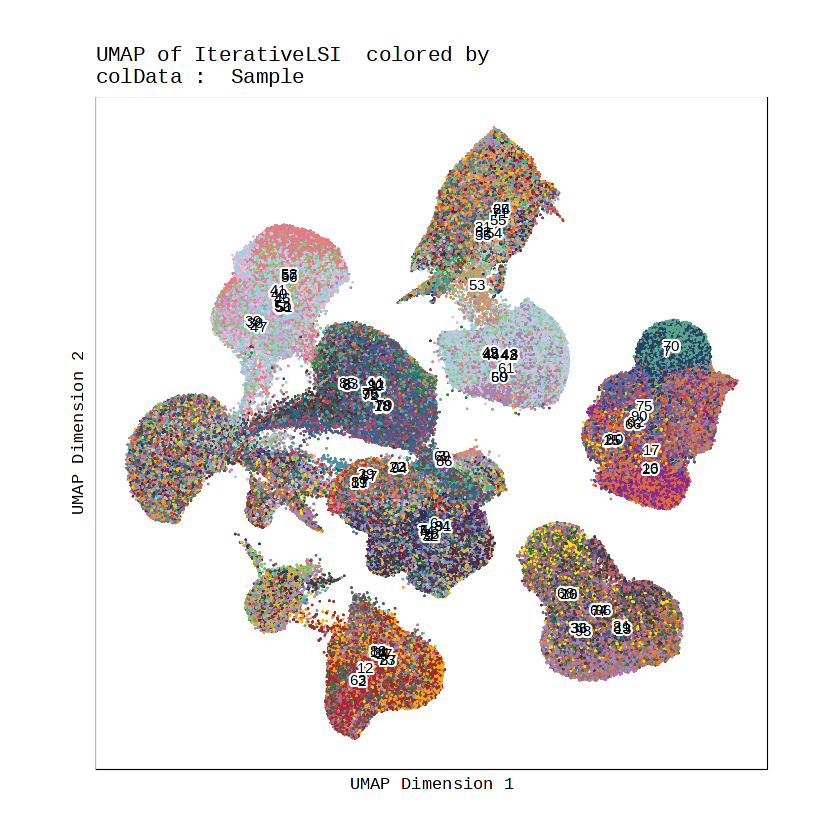

In [ ]:
p1

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-b12e186b480f-Date-2022-11-14_Time-10-12-20.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = cellColData

Plotting Embedding

1 
Length of unique values greater than palette, interpolating..



ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-b12e186b480f-Date-2022-11-14_Time-10-12-20.log



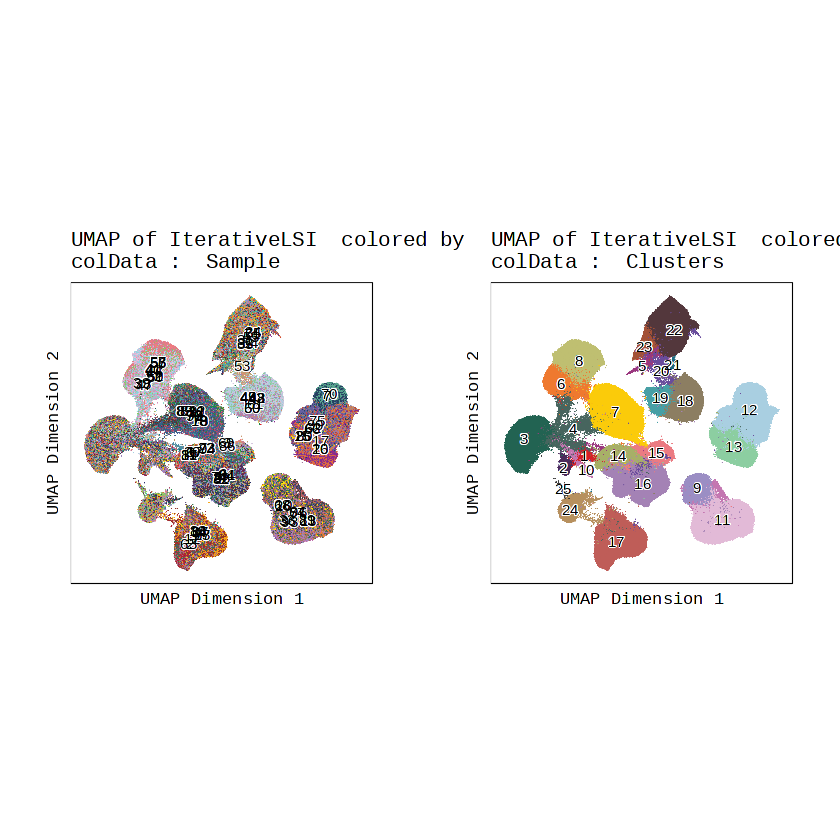

In [ ]:
p2 <- plotEmbedding(ArchRProj = proj, colorBy = "cellColData", name = "Clusters", embedding = "UMAP", show.legend = FALSE)+ 
theme(legend.position = "none")
ggAlignPlots(p1, p2, type = "h")

# Add GEX clusters

In [ ]:
GEX_ledien = read.csv('../data/metadata/barcodes/cell_types_GEX_leiden.csv')

In [ ]:
# setup GEX cluster merge
proj@cellColData$index = rownames(proj@cellColData)
row_order = proj@cellColData$index

In [ ]:
new_ColData = proj@cellColData %>% merge(GEX_ledien, by = 'index', all.x = T) %>%
    `rownames<-`(.$index) %>% 
    .[order(match(rownames(.), row_order)),]

order_preserved = all_equal(new_ColData[,c('index', 'index')], 
                            proj@cellColData[,c('index', 'index')], 
                            ignore_row_order = F)
print(order_preserved)

[1] TRUE


In [ ]:
if(order_preserved==T){
    proj@cellColData = new_ColData
}

# Add ATAC clusters

In [ ]:
ATAC_clusters = read.table('../data/metadata/ATAC_clusters.csv')

In [ ]:
ATAC_clusters$index = rownames(ATAC_clusters)
ATAC_clusters = ATAC_clusters[,c("index", "Clusters")]

In [ ]:
# setup GEX cluster merge
proj@cellColData$index = rownames(proj@cellColData)
row_order = proj@cellColData$index

In [ ]:
new_ColData = proj@cellColData %>% merge(ATAC_clusters, by = 'index', all.x = T) %>%
    `rownames<-`(.$index) %>% 
    .[order(match(rownames(.), row_order)),]

order_preserved = all_equal(new_ColData[,c('index', 'index')], 
                            proj@cellColData[,c('index', 'index')], 
                            ignore_row_order = F)
print(order_preserved)

In [ ]:
if(order_preserved==T){
    proj@cellColData = new_ColData
}

# Peak calling and merging

In [ ]:
proj <- addGroupCoverages(
    ArchRProj = proj, 
    groupBy = "Clusters"
)

ArchR logging to : ArchRLogs/ArchR-addGroupCoverages-2e7f13ac3ef0-Date-2022-11-19_Time-16-18-43.log
If there is an issue, please report to github with logFile!



ERROR: Error in addGroupCoverages(ArchRProj = proj, groupBy = "Clusters"): Group Coverages Already Computed, Set force = TRUE to continue!


In [ ]:
pathToMacs2 <- '../envs/ArchR_new/bin/macs2'

In [ ]:
proj <- addReproduciblePeakSet(
    ArchRProj = proj, 
    groupBy = "Clusters", 
    pathToMacs2 = pathToMacs2
)

ArchR logging to : ArchRLogs/ArchR-addReproduciblePeakSet-2e7f49de4cda-Date-2022-11-19_Time-16-19-14.log
If there is an issue, please report to github with logFile!

Calling Peaks with Macs2



In [ ]:
proj <- addPeakMatrix(proj)

ArchR logging to : ArchRLogs/ArchR-addPeakMatrix-2e7f3f4b9fa1-Date-2022-11-20_Time-13-58-42.log
If there is an issue, please report to github with logFile!

2022-11-20 13:58:45 : Batch Execution w/ safelapply!, 0 mins elapsed.

ArchR logging successful to : ArchRLogs/ArchR-addPeakMatrix-2e7f3f4b9fa1-Date-2022-11-20_Time-13-58-42.log



In [ ]:
sample_IDs = unique(proj@cellColData$Sample)
dir_name = "../data/archr_peaks/"
output_dir = "../data/archr_peaks/"

In [ ]:
lapply(sample_IDs, function(x){
    sample = x
    output_dir = paste0(dir_name,sample,"/")
    dir.create(output_dir)
    sample_proj = proj[proj@cellColData$Sample==sample,]
    
    # export relevant aspects of anndata
    mat = getMatrixFromProject(sample_proj, useMatrix='PeakMatrix')
    metadata = mat@colData
    var = rowRanges(mat)
    writeMM(mat@assays@data$PeakMatrix, file=paste0(output_dir,'mat.txt'))
    write.table(var, paste0(output_dir,'var.txt'), quote=F, sep=',')
    write.table(metadata, paste0(output_dir,'obs.txt'), quote=F, sep=',')
})

Warning message in dir.create(output_dir):
“'/lustre/scratch117/cellgen/team283/gd11/data_GBM/archr_peaks/cellranger-arc201_count_0160de26b05fc87120f8a269ad4e370d' already exists”
ArchR logging to : ArchRLogs/ArchR-getMatrixFromProject-2e7f22dd24b-Date-2022-11-20_Time-19-16-00.log
If there is an issue, please report to github with logFile!

2022-11-20 19:17:01 : Organizing colData, 1.001 mins elapsed.

2022-11-20 19:17:01 : Organizing rowData, 1.001 mins elapsed.

2022-11-20 19:17:01 : Organizing rowRanges, 1.001 mins elapsed.

2022-11-20 19:17:01 : Organizing Assays (1 of 1), 1.002 mins elapsed.

2022-11-20 19:17:01 : Constructing SummarizedExperiment, 1.002 mins elapsed.

2022-11-20 19:17:18 : Finished Matrix Creation, 1.291 mins elapsed.

ArchR logging to : ArchRLogs/ArchR-getMatrixFromProject-2e7f6e6799fc-Date-2022-11-20_Time-19-17-48.log
If there is an issue, please report to github with logFile!

2022-11-20 19:18:02 : Organizing colData, 0.232 mins elapsed.

2022-11-20 19:18:02 :

# Read Peaks from files

In [ ]:
peak_path <- "../data/archr_peaks/"
files <- list.files(path=peak_path, 
                    pattern="*rds",
                    all.files=T)       # Get all file names

In [ ]:
peaks = lapply(files, function(x){
    readRDS(paste0(peak_path,x))})

In [ ]:
peaks[[1]]

GRanges object with 150000 ranges and 11 metadata columns:
           seqnames              ranges strand |     score
              <Rle>           <IRanges>  <Rle> | <numeric>
       [1]     chr4 119454530-119455030      * |   1652.17
       [2]     chr7       149099-149599      * |   1136.37
       [3]     chr7     1459403-1459903      * |   1167.09
       [4]     chr7   44748241-44748741      * |   1069.76
       [5]     chr7   54781307-54781807      * |   2467.22
       ...      ...                 ...    ... .       ...
  [149996]    chr14   68955432-68955932      * |   4.36115
  [149997]    chr14   72177183-72177683      * |   4.36115
  [149998]    chr14   73260493-73260993      * |   4.36115
  [149999]    chr14   73739947-73740447      * |   4.36115
  [150000]    chr14   73885911-73886411      * |   4.36115
           replicateScoreQuantile groupScoreQuantile Reproducibility
                        <numeric>          <numeric>       <numeric>
       [1]                      1   

# Function corrections

In [ ]:
addIterativeLSI_ <- function(
  ArchRProj = NULL, 
  useMatrix = "TileMatrix",
  name = "IterativeLSI",
  iterations = 2,
  clusterParams = list(
      resolution = c(2), 
      sampleCells = 10000,
      maxClusters = 6,
      n.start = 10
  ),
  firstSelection = "top",
  depthCol = "nFrags",
  varFeatures = 25000,
  dimsToUse = 1:30,
  LSIMethod = 2,
  scaleDims = TRUE,
  corCutOff = 0.75,
  binarize = TRUE,
  outlierQuantiles = c(0.02, 0.98),
  filterBias = TRUE,
  sampleCellsPre = 10000,
  projectCellsPre = FALSE,
  selectionMethod = "var",
  scaleTo = 10000,
  totalFeatures = 500000,
  filterQuantile = 0.995,
  excludeChr = c(),
  saveIterations = TRUE,
  UMAPParams = list(
    n_neighbors = 40, 
    min_dist = 0.4, 
    metric = "cosine", 
    verbose = FALSE, 
    fast_sgd = TRUE
  ),
  nPlot = 10000,
  outDir = getOutputDirectory(ArchRProj),
  threads = getArchRThreads(),
  seed = 1,
  verbose = TRUE,
  force = FALSE,
  logFile = createLogFile("addIterativeLSI")
  ){
  
  if(verbose) message("Checking Inputs...")
  .validInput(input = ArchRProj, name = "ArchRProj", valid = c("ArchRProj"))
  .validInput(input = useMatrix, name = "useMatrix", valid = c("character"))
  .validInput(input = name, name = "name", valid = c("character"))
  .validInput(input = iterations, name = "iterations", valid = c("integer"))
  .validInput(input = clusterParams, name = "clusterParams", valid = c("list"))
  .validInput(input = varFeatures, name = "varFeatures", valid = c("integer"))
  .validInput(input = dimsToUse, name = "dimsToUse", valid = c("integer"))
  .validInput(input = LSIMethod, name = "LSIMethod", valid = c("integer", "character"))
  .validInput(input = scaleDims, name = "scaleDims", valid = c("boolean"))
  .validInput(input = corCutOff, name = "corCutOff", valid = c("numeric"))
  .validInput(input = binarize, name = "binarize", valid = c("boolean"))
  .validInput(input = outlierQuantiles, name = "outlierQuantiles", valid = c("numeric", "null"))
  .validInput(input = filterBias, name = "filterBias", valid = c("boolean"))
  .validInput(input = sampleCellsPre, name = "sampleCellsPre", valid = c("integer", "null"))
  .validInput(input = sampleCellsFinal, name = "sampleCellsFinal", valid = c("integer", "null"))
  .validInput(input = selectionMethod, name = "selectionMethod", valid = c("character"))
  .validInput(input = scaleTo, name = "scaleTo", valid = c("numeric"))
  .validInput(input = totalFeatures, name = "totalFeatures", valid = c("integer"))
  .validInput(input = filterQuantile, name = "filterQuantile", valid = c("numeric"))
  .validInput(input = excludeChr, name = "excludeChr", valid = c("character", "null"))
  .validInput(input = saveIterations, name = "saveIterations", valid = c("boolean"))
  .validInput(input = UMAPParams, name = "UMAPParams", valid = c("list"))
  .validInput(input = nPlot, name = "nPlot", valid = c("integer"))
  .validInput(input = outDir, name = "outDir", valid = c("character"))
  .validInput(input = threads, name = "threads", valid = c("integer"))
  .validInput(input = seed, name = "seed", valid = c("integer"))
  .validInput(input = verbose, name = "verbose", valid = c("boolean"))
  .validInput(input = force, name = "force", valid = c("boolean"))
  .validInput(input = logFile, name = "logFile", valid = c("character"))


  if(varFeatures < 1000){
    stop("Please provide more than 1000 varFeatures!")
  }

  .startLogging(logFile = logFile)
  .logThis(mget(names(formals()),sys.frame(sys.nframe())), "IterativeLSI Input-Parameters", logFile=logFile)

  .requirePackage("Matrix", source = "cran")
  tstart <- Sys.time()

  if(!is.null(ArchRProj@reducedDims[[name]])){
    if(!force){
      stop("Error name in reducedDims Already Exists! Set force = TRUE or pick a different name!")
    }
  }

  #Set Seed
  set.seed(seed)
  outDir <- file.path(outDir, name)
  dir.create(outDir, showWarnings = FALSE, recursive = TRUE)

  #All the Cell Names
  cellNames <- rownames(getCellColData(ArchRProj))
  if(!is.null(sampleCellsPre)){
    if(length(cellNames) < sampleCellsPre){
      sampleCellsPre <- NULL
    }
  }
  if(!is.null(sampleCellsFinal)){
    if(length(cellNames) < sampleCellsFinal){
      sampleCellsFinal <- NULL
    }
  }

  #MatrixFiles
  ArrowFiles <- getSampleColData(ArchRProj)[,"ArrowFiles"]

  #Check if Matrix is supported and check type
  if(tolower(useMatrix) == "tilematrix"){
    useMatrix <- "TileMatrix"
    tileSizes <- lapply(ArrowFiles, function(x){
      h5read(x, "TileMatrix/Info/Params/")$tileSize[1]
    }) %>% unlist
    if(length(unique(tileSizes)) != 1){
      stop("Error not all TileMatrices are the same tileSize!")
    }
    tileSize <- unique(tileSizes)
  }else if(tolower(useMatrix) == "peakmatrix"){
    useMatrix <- "PeakMatrix"
    tileSize <- NA
  }else{
    tileSize <- NA
  }

  units <- unique(unlist(lapply(ArrowFiles, function(x) h5read(x, paste0(useMatrix, "/Info/Units")))))
  if(length(units) != 1){
    stop("Units of matrices are not identical!")
  }
  if(grepl("log",units,ignore.case=TRUE)){
    stop("Cannot use log transformed values for iterativeLSI!")
  }

  tstart <- Sys.time()  
  ############################################################################################################################
  # Organize Information for LSI
  ############################################################################################################################
  chrToRun <- .availableSeqnames(ArrowFiles, subGroup = useMatrix)

  if(tolower(firstSelection) == "top"){
    
    if(!binarize){
      matClass <- h5read(ArrowFiles[1], paste0(useMatrix,"/Info/Class"))
      if(matClass != "Sparse.Binary.Matrix"){
        stop("Input matrix is not binarized and binarize != TRUE. Please use binarized data if using top selection for first iteration! Set binarize = TRUE!")
      }
    }

    #Compute Row Sums Across All Samples
    .logDiffTime("Computing Total Across All Features", tstart, addHeader = FALSE, verbose = verbose, logFile = logFile)
    if(useMatrix == "TileMatrix"){
      totalAcc <- .getRowSums(ArrowFiles = ArrowFiles, useMatrix = useMatrix, seqnames = chrToRun, addInfo = FALSE)
      totalAcc$start <- (totalAcc$idx - 1) * tileSize
    }else{
      totalAcc <- .getRowSums(ArrowFiles = ArrowFiles, useMatrix = useMatrix, seqnames = chrToRun, addInfo = TRUE)
    }

    #Filter Chromosomes
    if(length(excludeChr) > 0){
      totalAcc <- totalAcc[BiocGenerics::which(totalAcc$seqnames %bcni% excludeChr), , drop = FALSE]
    }

    #Identify the top features to be used here
    .logDiffTime("Computing Top Features", tstart, addHeader = FALSE, verbose = verbose, logFile = logFile)
    nFeature <- varFeatures[1]
    rmTop <- floor((1-filterQuantile) * totalFeatures)
    topIdx <- head(order(totalAcc$rowSums, decreasing=TRUE), nFeature + rmTop)[-seq_len(rmTop)]
    topFeatures <- totalAcc[sort(topIdx),]

    gc()

  }else if(tolower(firstSelection) %in% c("var", "variable")){

    if(binarize){
      stop("Please do not binarize data if using variable selection for first iteration! Set binarize = FALSE!")
    }

    if(units %in% "BinarizedCounts"){
      stop("Cannot do variable selection with BinarizedCounts. Set firstSelection = Top!")
    }

    #Compute Row Sums Across All Samples
    .logDiffTime("Computing Variability Across All Features", tstart, addHeader = FALSE, verbose = verbose, logFile = logFile)
    if(useMatrix == "TileMatrix"){
      totalAcc <- .getRowVars(ArrowFiles = ArrowFiles, useMatrix = useMatrix, seqnames = chrToRun, useLog2 = TRUE)
      totalAcc$start <- (totalAcc$idx - 1) * tileSize
    }else{
      totalAcc <- .getRowVars(ArrowFiles = ArrowFiles, useMatrix = useMatrix, seqnames = chrToRun, useLog2 = TRUE)
    }

    #Filter Chromosomes
    if(length(excludeChr) > 0){
      totalAcc <- totalAcc[BiocGenerics::which(totalAcc$seqnames %bcni% excludeChr), , drop = FALSE]
    }

    #Identify the top features to be used here
    .logDiffTime("Computing Variable Features", tstart, addHeader = FALSE, verbose = verbose, logFile = logFile)
    nFeature <- varFeatures[1]
    if(nFeature > 0.5 * nrow(totalAcc)){
      stop("nFeature for variable selection must be less than 1/2 the total features!")
    }
    topIdx <- head(order(totalAcc$combinedVars, decreasing=TRUE), nFeature)
    topFeatures <- totalAcc[sort(topIdx),]

    gc()

  }else{

    stop("firstSelect method must be Top or Var/Variable!")

  }

  cellDepth <- tryCatch({
      df <- getCellColData(ArchRProj = ArchRProj, select = depthCol)
      v <- df[,1]
      names(v) <- rownames(df)
      v
    }, error = function(e){
      tryCatch({
        .getColSums(ArrowFiles = ArrowFiles, useMatrix = useMatrix, seqnames = chrToRun)[ArchRProj$cellNames]
      }, error = function(y){
        stop("Could not determine depth from depthCol or colSums!")
      })
    }
  )
  cellDepth <- log10(cellDepth + 1)

  ############################################################################################################################
  # LSI Iteration 1
  ############################################################################################################################
  .logDiffTime(paste0("Running LSI (1 of ",iterations,") on Top Features"), tstart, addHeader = TRUE, verbose = verbose, logFile = logFile)
  j <- 1

  if(!is.null(clusterParams$sampleCells)){
    if(!is.na(clusterParams$sampleCells[j])){
      sampleJ <- clusterParams$sampleCells[j]
    }else if(!is.na(clusterParams$sampleCells[1])){
      sampleJ <- clusterParams$sampleCells[1]
    }else{
      sampleJ <- sampleCellsPre
    }
  }else{
    sampleJ <- sampleCellsPre 
  }

  outLSI <- .LSIPartialMatrix(
    ArrowFiles = ArrowFiles, 
    featureDF = topFeatures,
    cellNames = cellNames, 
    cellDepth = cellDepth,
    useMatrix = useMatrix,
    sampleNames = getCellColData(ArchRProj)$Sample, 
    LSIMethod = LSIMethod, 
    scaleTo = scaleTo,
    dimsToUse = dimsToUse, 
    binarize = binarize, 
    outlierQuantiles = outlierQuantiles,
    sampleCells = if(j != iterations) sampleCellsPre else sampleCellsFinal,
    projectAll = j == iterations | projectCellsPre | sampleJ > sampleCellsPre,
    threads = threads,
    useIndex = FALSE,
    seed = seed,
    tstart = tstart,
    verbose = verbose,
    logFile = logFile
  )
  outLSI$scaleDims <- scaleDims
  outLSI$useMatrix <- useMatrix
  outLSI$tileSize <- tileSize
  gc()
  .logThis(outLSI, paste0("outLSI-",j), logFile = logFile)

  if(iterations == 1){
    .logDiffTime("Finished Running IterativeLSI", tstart, addHeader = FALSE, verbose = verbose, logFile = logFile)
    ArchRProj@reducedDims[[name]] <- outLSI
    #.endLogging(logFile = logFile)
    return(ArchRProj)
  }

  #########################
  # Identify LSI Clusters
  #########################
  clusterDF <- .LSICluster(
    outLSI = outLSI,
    filterBias = filterBias,
    cellNames = cellNames,
    cellDepth = cellDepth,
    dimsToUse = dimsToUse,
    scaleDims = scaleDims,
    corCutOff = corCutOff,
    clusterParams = clusterParams,
    j = j,
    verbose = verbose,
    tstart = tstart,
    logFile = logFile
  )
  clusters <- clusterDF$clusters
  nClust <- length(unique(clusters))
  .logDiffTime(sprintf("Identified %s Clusters", nClust), tstart, addHeader = FALSE, verbose = verbose, logFile = logFile)
  .logThis(clusterDF, paste0("clusterDF-",j), logFile = logFile)

  #########################
  # Save LSI Iteration
  #########################
  if(saveIterations){
    .logDiffTime("Saving LSI Iteration", tstart, addHeader = FALSE, verbose = verbose, logFile = logFile)
    .saveIteration(outLSI=outLSI, clusters=clusters, scaleDims = scaleDims, 
      dimsToUse = dimsToUse, corCutOff = corCutOff, outDir = outDir,
      nPlot=nPlot, UMAPParams=UMAPParams, ArchRProj=ArchRProj, j = j, threads = threads, logFile = logFile)
  }

  ############################################################################################################################
  # LSI Iteration 2+
  ############################################################################################################################
  variableFeatures <- topFeatures

  while(j < iterations){

    #Jth iteration
    j <- j + 1

    #########################
    # Identify Features for LSI Iteration
    #########################
    variableFeatures <- .identifyVarFeatures(
      outLSI = outLSI,
      clusterDF = clusterDF,
      ArrowFiles = ArrowFiles,
      useMatrix = useMatrix,
      prevFeatures = variableFeatures,
      scaleTo = scaleTo,
      totalAcc = totalAcc,
      totalFeatures = totalFeatures,
      firstSelection = firstSelection,
      selectionMethod = selectionMethod,
      varFeatures = varFeatures,
      tstart = tstart,
      threads = threads,
      verbose = verbose,
      logFile = logFile
    )

    #########################
    # LSI
    #########################
    .logDiffTime(sprintf("Running LSI (%s of %s) on Variable Features", j, iterations), tstart, addHeader = TRUE, verbose = verbose, logFile = logFile)
    if(!is.null(clusterParams$sampleCells)){
      if(!is.na(clusterParams$sampleCells[j])){
        sampleJ <- clusterParams$sampleCells[j]
      }else if(!is.na(clusterParams$sampleCells[1])){
        sampleJ <- clusterParams$sampleCells[1]
      }else{
        sampleJ <- sampleCellsPre
      }
    }else{
      sampleJ <- sampleCellsPre 
    }

    #Compute Partial Matrix LSI
    outLSI <- .LSIPartialMatrix(
      ArrowFiles = ArrowFiles, 
      featureDF = variableFeatures,
      useMatrix = useMatrix,
      cellNames = cellNames, 
      cellDepth = cellDepth,
      sampleNames = getCellColData(ArchRProj)$Sample, 
      LSIMethod = LSIMethod, 
      scaleTo = scaleTo, 
      dimsToUse = dimsToUse,
      binarize = binarize,
      outlierQuantiles = outlierQuantiles, 
      sampleCells = if(j != iterations) sampleCellsPre else sampleCellsFinal,
      projectAll = j == iterations | projectCellsPre | sampleJ > sampleCellsPre,
      threads = threads,
      useIndex = FALSE,
      seed = seed,
      tstart = tstart,
      verbose = verbose,
      logFile = logFile
    )
    outLSI$scaleDims <- scaleDims
    outLSI$useMatrix <- useMatrix
    outLSI$tileSize <- tileSize
    .logThis(outLSI, paste0("outLSI-",j), logFile = logFile)

    if(j != iterations){

      #########################
      # Identify LSI Clusters
      #########################
      clusterDF <- .LSICluster(
        outLSI = outLSI,
        dimsToUse = dimsToUse,
        scaleDims = scaleDims,
        corCutOff = corCutOff,
        filterBias = filterBias,
        cellNames = cellNames,
        cellDepth = cellDepth,
        j = j,
        clusterParams = clusterParams,
        verbose = verbose,
        tstart = tstart,
        logFile = logFile
      )
      clusters <- clusterDF$clusters
      nClust <- length(unique(clusters))
      .logDiffTime(sprintf("Identified %s Clusters", nClust), tstart, addHeader = FALSE, verbose = verbose, logFile = logFile)
      .logThis(clusterDF, paste0("clusterDF-",j), logFile = logFile)

      #########################
      # Save LSI Iteration
      #########################
      if(saveIterations){
        .logDiffTime("Saving LSI Iteration", tstart, addHeader = FALSE, verbose = verbose, logFile = logFile)
        .saveIteration(outLSI=outLSI, clusters=clusters, scaleDims = scaleDims, 
          dimsToUse = dimsToUse, corCutOff = corCutOff, outDir = outDir,
          nPlot=nPlot, UMAPParams=UMAPParams, ArchRProj=ArchRProj, j = j, threads = threads, logFile = logFile)
      }

    }

    gc()

  }

  #Organize Output
  .logDiffTime("Finished Running IterativeLSI", tstart, addHeader = FALSE, verbose = verbose, logFile = logFile)
  ArchRProj@reducedDims[[name]] <- outLSI

  return(ArchRProj)

}

#########################################################################################
# LSI On Partial Matrix
#########################################################################################
.LSIPartialMatrix <- function(
  ArrowFiles = NULL, 
  featureDF = NULL, 
  useMatrix = NULL,
  cellNames = NULL, 
  cellDepth = NULL,
  sampleNames = NULL, 
  dimsToUse = NULL, 
  binarize = TRUE, 
  outlierQuantiles = c(0.02, 0.98),
  LSIMethod = FALSE,
  scaleTo = 10^4,
  sampleCells = 5000, 
  projectAll = TRUE,
  threads = 1, 
  seed = 1,
  useIndex = FALSE, 
  tstart = NULL, 
  verbose = TRUE,
  logFile = NULL
  ){

  if(is.null(tstart)){
    tstart <- Sys.time()
  }

  errorList <- append(args, mget(names(formals()),sys.frame(sys.nframe())))

  outLSI2 <- tryCatch({

    if(is.null(sampleCells)){
      
      #Construct Matrix
      .logDiffTime("Creating Partial Matrix", tstart, addHeader = FALSE, verbose = verbose, logFile = logFile)
      
      mat <- .getPartialMatrix(
        ArrowFiles = ArrowFiles,
        featureDF = featureDF,
        useMatrix = useMatrix,
        cellNames = cellNames,
        doSampleCells = FALSE,
        threads = threads,
        verbose = FALSE,
        logFile = logFile
      )

      #Compute LSI
      .logDiffTime("Computing LSI", tstart, addHeader = FALSE, verbose = verbose, logFile = logFile)
      outLSI <- .computeLSI(
       mat = mat, 
       LSIMethod = LSIMethod, 
       scaleTo = scaleTo,
       nDimensions = max(dimsToUse),
       binarize = binarize, 
       outlierQuantiles = outlierQuantiles,
       verbose = FALSE, 
       seed = seed,
       tstart = tstart,
       logFile = logFile
      )
      outLSI$LSIFeatures <- featureDF
      outLSI$corToDepth <- list(
        scaled = abs(cor(.scaleDims(outLSI[[1]]), cellDepth[rownames(outLSI[[1]])]))[,1],
        none = abs(cor(outLSI[[1]], cellDepth[rownames(outLSI[[1]])]))[,1]
      )

    }else{
     
      sampledCellNames <- .sampleBySample(
        cellNames = cellNames,
        sampleNames = sampleNames,
        cellDepth = cellDepth,
        sampleCells = sampleCells,
        outlierQuantiles = outlierQuantiles,
        factor = 2      
      )
      .logDiffTime(sprintf("Sampling Cells (N = %s) for Estimated LSI", length(sampledCellNames)), tstart, addHeader = FALSE, verbose = verbose, logFile = logFile)

      #Construct Sampled Matrix
      .logDiffTime("Creating Sampled Partial Matrix", tstart, addHeader = FALSE, verbose = verbose, logFile = logFile)
      o <- h5closeAll()
      if(!projectAll){

        mat <- .getPartialMatrix(
          ArrowFiles = ArrowFiles,
          featureDF = featureDF,
          useMatrix = useMatrix,
          cellNames = sampledCellNames,
          doSampleCells = FALSE,
          threads = threads,
          verbose = FALSE,
          logFile = logFile
        )

        #Compute LSI
        .logDiffTime("Computing Estimated LSI (projectAll = FALSE)", tstart, addHeader = FALSE, verbose = verbose, logFile = logFile)
        outLSI <- .computeLSI(
         mat = mat, 
         LSIMethod = LSIMethod, 
         scaleTo = scaleTo,
         nDimensions = max(dimsToUse),
         binarize = binarize, 
         outlierQuantiles = outlierQuantiles,
         seed = seed,
         tstart = tstart,
         logFile = logFile
        )
        outLSI$LSIFeatures <- featureDF
        outLSI$corToDepth <- list(
          scaled = abs(cor(.scaleDims(outLSI[[1]]), cellDepth[rownames(outLSI[[1]])]))[,1],
          none = abs(cor(outLSI[[1]], cellDepth[rownames(outLSI[[1]])]))[,1]
        )

      }else{

        tmpPath <- .tempfile(pattern = "tmp-LSI-PM", tmpdir = "../tmp/")

        .logDiffTime(sprintf("Sampling Cells (N = %s) for Estimated LSI", length(sampledCellNames)), tstart, addHeader = FALSE, verbose = verbose, logFile = logFile)
        out <- .getPartialMatrix(
            ArrowFiles = ArrowFiles,
            featureDF = featureDF,
            useMatrix = useMatrix,
            cellNames = cellNames,
            doSampleCells = TRUE,
            sampledCellNames = sampledCellNames,
            tmpPath = tmpPath,
            useIndex = useIndex,
            threads = threads,
            verbose = FALSE,
            logFile = logFile
          )
        gc()

        #Perform LSI on Partial Sampled Matrix
        .logDiffTime("Computing Estimated LSI (projectAll = TRUE)", tstart, addHeader = FALSE, verbose = verbose, logFile = logFile)
        outLSI <- .computeLSI(
           mat = out$mat, 
           LSIMethod = LSIMethod, 
           scaleTo = scaleTo,
           nDimensions = max(dimsToUse),
           binarize = binarize, 
           outlierQuantiles = outlierQuantiles,
           seed = seed,
           tstart = tstart,
           logFile = logFile
          )

        tmpMatFiles <- out[[2]]
        rm(out)
        gc()

        #Read In Matrices and Project into Manifold
        #Do Threads / 3 just in case of memory here (Needs testing QQQ)
        threads2 <- 1 #max(ceiling(threads / 3), 1)
        .logDiffTime("Projecting Matrices with LSI-Projection (Granja* et al 2019)", tstart, addHeader = FALSE, verbose = verbose, logFile = logFile)
        pLSI <- .safelapply(seq_along(tmpMatFiles), function(x){
          .logDiffTime(sprintf("Projecting Matrix (%s of %s) with LSI-Projection", x, length(tmpMatFiles)), tstart, addHeader = FALSE, verbose = FALSE, logFile = logFile)
          .projectLSI(mat = readRDS(tmpMatFiles[x]), LSI = outLSI, verbose = FALSE, tstart = tstart, logFile = logFile)
        }, threads = threads2) %>% Reduce("rbind", .)

        #Remove Temporary Matrices
        rmf <- file.remove(tmpMatFiles)

        #Set To LSI the SVD Matrices
        outLSI$exlcude <- cellNames[which(cellNames %ni% rownames(pLSI))]
        outLSI$matSVD <- as.matrix(pLSI[cellNames[which(cellNames %in% rownames(pLSI))],])

      }

      outLSI$LSIFeatures <- featureDF
      outLSI$corToDepth <- list(
        scaled = abs(cor(.scaleDims(outLSI[[1]]), cellDepth[rownames(outLSI[[1]])]))[,1],
        none = abs(cor(outLSI[[1]], cellDepth[rownames(outLSI[[1]])]))[,1]
      )

    }

    outLSI

  }, error = function(e){

    errorList$outLSI <- if(exists("outLSI", inherits = FALSE)) outLSI else "Error with outLSI!"
    errorList$matSVD <- if(exists("outLSI", inherits = FALSE)) outLSI[[1]] else "Error with matSVD!"

    .logError(e, fn = ".LSIPartialMatrix", info = "", errorList = errorList, logFile = logFile)

  })

  return(outLSI2)

}


#########################################################################################
# Sampling Helpers
#########################################################################################
.filterSample <- function(
  x = NULL, 
  n = NULL, 
  vals = x, 
  outlierQuantiles = NULL, 
  factor = 2, 
  ...
  ){
  if(!is.null(outlierQuantiles)){
    quant <- quantile(vals, probs = c(min(outlierQuantiles) / factor, 1 - ((1-max(outlierQuantiles)) / factor)))
    idx <- which(vals >= quant[1] & vals <= quant[2])
  }else{
    idx <- seq_along(x)
  }
  if(length(idx) >= n){
    sample(x = x[idx], size = n)
  }else{
    sample(x = x, size = n)
  }
}

.sampleBySample <- function(
  cellNames = NULL, 
  cellDepth = NULL, 
  sampleNames = NULL, 
  sampleCells = NULL, 
  outlierQuantiles = NULL, 
  factor = 2
  ){

  if(sampleCells < length(cellNames)){

    sampleN <- ceiling(sampleCells * table(sampleNames) / length(sampleNames))
    splitCells <- split(cellNames, sampleNames)
    splitDepth <- split(cellDepth, sampleNames)

    sampledCellNames <- lapply(seq_along(splitCells), function(x){
      .filterSample(
        x = splitCells[[x]], 
        n = sampleN[names(splitCells)[x]], 
        vals = splitDepth[[x]], 
        outlierQuantiles = outlierQuantiles, 
        factor = factor
      )
    }) %>% unlist %>% sort

    return(sampledCellNames)
  
  }else{

    return(cellNames)

  }

}